In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('../data/final_data.csv')
df.shape

(5281, 16)

In [4]:
import joblib

model = joblib.load("../results/model.pkl")
scaler = joblib.load("../results/scaler.pkl")

In [5]:
X = df.drop(columns=['P_HABITABLE'])
y = df['P_HABITABLE']

X.shape, y.shape

((5281, 15), (5281,))

In [6]:
X_scaled = scaler.transform(X)
df['ML_probability'] = model.predict_proba(X_scaled)[:, 1]

In [7]:
R_earth = 1.0
M_earth = 1.0
F_earth = 1.0
T_earth = 255.0     # Kelvin

In [ ]:
def H_radius(R):
    return np.exp(-((R - 1.0) / 0.5)**2)

def H_mass(M):
    return np.exp(-((M - 1.0) / 0.5)**2)

def H_flux(F):
    return np.exp(-((F - 1.0) / 0.75)**2)

def H_temp(T):
    return np.exp(-((T - 255.0) / 50.0)**2)

In [10]:
df = df.copy()

df['H_radius'] = H_radius(df['P_RADIUS'])
df['H_mass']   = H_mass(df['P_MASS'])
df['H_flux']   = H_flux(df['P_FLUX'])
df['H_temp']   = H_temp(df['P_TEMP_EQUIL'])

In [12]:
df['H_proxy'] = (
    df['H_radius'] *
    df['H_mass'] *
    df['H_flux'] *
    df['H_temp']
)

In [13]:
mask = df[['H_proxy', 'ML_probability']].notna().all(axis=1)

df_valid = df[mask]

df_valid.shape

(5281, 22)

In [17]:
df_valid[['P_RADIUS','P_MASS','P_FLUX','P_TEMP_EQUIL','H_proxy']].describe()

,P_RADIUS,P_MASS,P_FLUX,P_TEMP_EQUIL,H_proxy
count,5281.000000,5281.000000,5.281000e+03,5281.000000,5281.000000
mean,5.435422,379.605674,5.588614e+02,796.317830,0.001203
std,5.127649,2269.993012,1.036439e+04,460.812533,0.026169
min,0.310000,0.037400,3.289901e-10,1.084914,0.000000
25%,1.740000,3.890000,1.135083e+01,464.687090,0.000000
50%,2.690000,8.220000,6.868239e+01,731.360330,0.000000
75%,10.760000,116.780270,2.949354e+02,1053.342800,0.000000
max,32.600000,89700.000000,6.363521e+05,7194.888800,0.876882


In [14]:
from scipy.stats import pearsonr, spearmanr

y_ml = df_valid['ML_probability']
y_proxy = df_valid['H_proxy']

print("Pearson:", pearsonr(y_ml, y_proxy))
print("Spearman:", spearmanr(y_ml, y_proxy))

Pearson: PearsonRResult(statistic=np.float64(0.3830604331665259), pvalue=np.float64(3.568948559169915e-184))
Spearman: SignificanceResult(statistic=np.float64(0.2924422302368189), pvalue=np.float64(1.2302102354728131e-104))


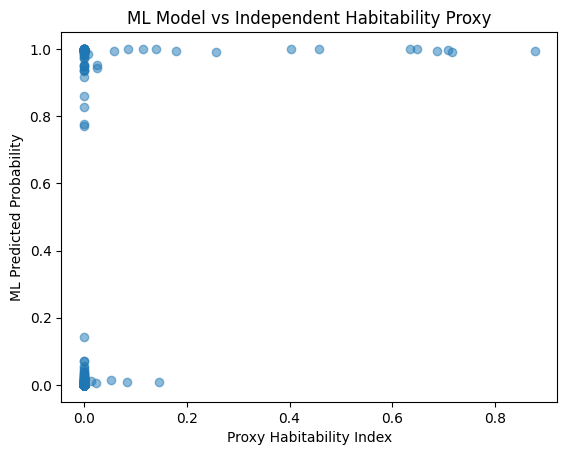

In [15]:
plt.figure()
plt.scatter(y_proxy, y_ml, alpha=0.5)

plt.xlabel("Proxy Habitability Index")
plt.ylabel("ML Predicted Probability")
plt.title("ML Model vs Independent Habitability Proxy")

plt.show();

In [16]:
threshold_ml = np.percentile(y_ml, 90)
threshold_proxy = np.percentile(y_proxy, 90)

top_ml = y_ml >= threshold_ml
top_proxy = y_proxy >= threshold_proxy

overlap = np.sum(top_ml & top_proxy) / np.sum(top_ml)

print("Top 10% overlap:", overlap);

Top 10% overlap: 0.3553875236294896
